# About Dataset
This dataset provides real-time data for smart logistics operations, capturing various aspects of supply chain management over the past year (2024). It includes information on asset tracking, inventory levels, shipment statuses, environmental conditions, traffic, and user behaviors. The dataset features multiple stakeholders within the logistics network, including asset IDs, timestamps, traffic conditions, waiting times, and reasons for delays. Additionally, the data is enriched with real-time information from IoT sensors, such as temperature, humidity, and asset utilization, to facilitate advanced logistics optimization and decision-making. The target variable, Logistics_Delay, helps in identifying delays in logistics processes, which is essential for enhancing supply chain efficiency through proactive management and optimization techniques. This dataset is designed to be used for research and machine learning applications focused on smart logistics and supply chain performance improvement.

## Key Features:
**Timestamp**: Date and time when the data was recorded, representing logistics activity.

**Asset_ID**: Unique identifier for the logistical assets (e.g., trucks).

**Latitude & Longitude**: Geographical coordinates of the asset for tracking and monitoring.

**Inventory_Level**: Current level of inventory associated with the asset or shipment.

**Shipment_Status**: Status of the shipment (e.g., In Transit, Delivered, Delayed).

**Temperature**: Temperature recorded at the time of the shipment or transportation.

**Humidity**: Humidity level at the time of recording.

**Traffic_Status**: Current traffic condition (e.g., Clear, Heavy, Detour).

**Waiting_Time**: Time spent waiting during the logistics process (in minutes).

**User_Transaction_Amount**: Monetary amount associated with user transactions.

**User_Purchase_Frequency**: Frequency of purchases made by the user.

**Logistics_Delay_Reason**: Reason for any delays in the logistics process (e.g., Weather, Mechanical Failure).

**Asset_Utilization**: Percentage of asset utilization, indicating how effectively assets are being used.

**Demand_Forecast**: Predicted demand for the logistics services in the coming period.

**Logistics_Delay (Target)**: Binary variable indicating whether a logistics delay occurred (1 for delay, 0 for no delay).

# Initial Data Exploration and Analysis
In this section, I will perform an initial exploration of the smart_logistics_dataset.csv to understand its structure, identify any data quality issues, and gain insights through univariate and bivariate analysis. This step is crucial for informing subsequent feature engineering and model selection. All analysis will be conducted in Google Colab using Python libraries: pandas for data manipulation, matplotlib and seaborn for visualisation.

## Setting Up the Environment and Loading Data
First, I mount my Google Drive to access the dataset file. I then import the required libraries and load the CSV into a pandas DataFrame.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
# Load dataset (adjust path to your file location)
file_path = '/content/drive/MyDrive/Colab Notebooks/UWS/Ivy/smart_logistics_dataset.csv'
df = pd.read_csv(file_path)

In [4]:
# Display first few rows
df.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


### Initial Data Inspection
I begin by examining the basic structure of the dataset using .info() and .describe(). This gives an overview of column data types, non-null counts, and summary statistics for numerical features.

In [5]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   object 
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    object 
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          

The output shows that all columns have 1000 entries (as expected from the sample). Most columns are numerical, while a few (`Timestamp`, `Asset_ID`, `Shipment_Status`, `Traffic_Status`, `Logistics_Delay_Reason`) are of object type and will need encoding later. Critically, we see that `Logistics_Delay_Reason` has only 737 non‑null values – meaning 263 entries are missing. All other columns have 1000 non‑null values, indicating no missing data elsewhere.

In [6]:
# Summary statistics for numerical columns
df.describe()

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-1.360093,0.837049,297.915000,23.893900,65.042200,35.062000,299.055000,5.513000,79.599100,199.284000,0.566000
std,51.997183,104.843618,113.554773,3.322178,8.753765,14.477768,117.787792,2.935379,11.631153,59.920847,0.495873
min,-89.791500,-179.820200,100.000000,18.000000,50.000000,10.000000,100.000000,1.000000,60.000000,100.000000,0.000000
25%,-46.167975,-88.448075,201.000000,21.200000,57.200000,23.000000,191.750000,3.000000,69.475000,144.000000,0.000000
50%,-4.503150,0.678300,299.000000,23.800000,65.200000,35.000000,301.500000,6.000000,79.250000,202.000000,1.000000
75%,44.502800,88.156450,399.000000,26.600000,72.400000,49.000000,405.000000,8.000000,89.425000,251.250000,1.000000
max,89.870100,179.923700,500.000000,30.000000,80.000000,60.000000,500.000000,10.000000,100.000000,300.000000,1.000000


The descriptive statistics reveal that:

- Inventory_Level ranges from 100 to 500.

- Temperature varies between 18.0°C and 30.0°C, with a mean around 24°C.

- Humidity spans 50% to 80%, mean ~65%.

- Waiting_Time ranges from 10 to 60 minutes.

- User_Transaction_Amount from 100 to 500.

- User_Purchase_Frequency from 1 to 10.

- Asset_Utilization from 60% to 100%.

- Demand_Forecast from 100 to 300.

- The target variable Logistics_Delay has a mean of ~0.55, indicating a fairly balanced class distribution (55% delays, 45% no delay).

### Handling Missing Values
Because `.info()` revealed missing values only in `Logistics_Delay_Reason`, I explicitly confirm with `.isnull().sum()`:

In [7]:
df.isnull().sum()

,0
Timestamp,0
Asset_ID,0
Latitude,0
Longitude,0
Inventory_Level,0
Shipment_Status,0
Temperature,0
Humidity,0
Traffic_Status,0
Waiting_Time,0


The 263 missing values in `Logistics_Delay_Reason` are likely cases where no reason was recorded. This could be because:

- There was no delay (Logistics_Delay = 0), so a reason is not applicable.

- A delay occurred but the reason was not captured (e.g., data entry omission).

During preprocessing, I will handle these missing values by imputing them with a new category '`no_reason`'. This approach preserves the information that a reason was absent while allowing the variable to be used as a categorical feature. It is a common and transparent way to treat missingness in categorical data. The imputation will be done after splitting the data to avoid data leakage, but for the purpose of EDA, we can examine the column with missing values as they are.

# Univariate Analysis
I now examine each feature individually to understand its distribution.

## Numerical Features
For numerical columns, I plot histograms with kernel density estimates (KDE) to visualise their distributions. This helps identify skewness, outliers, and potential data issues.

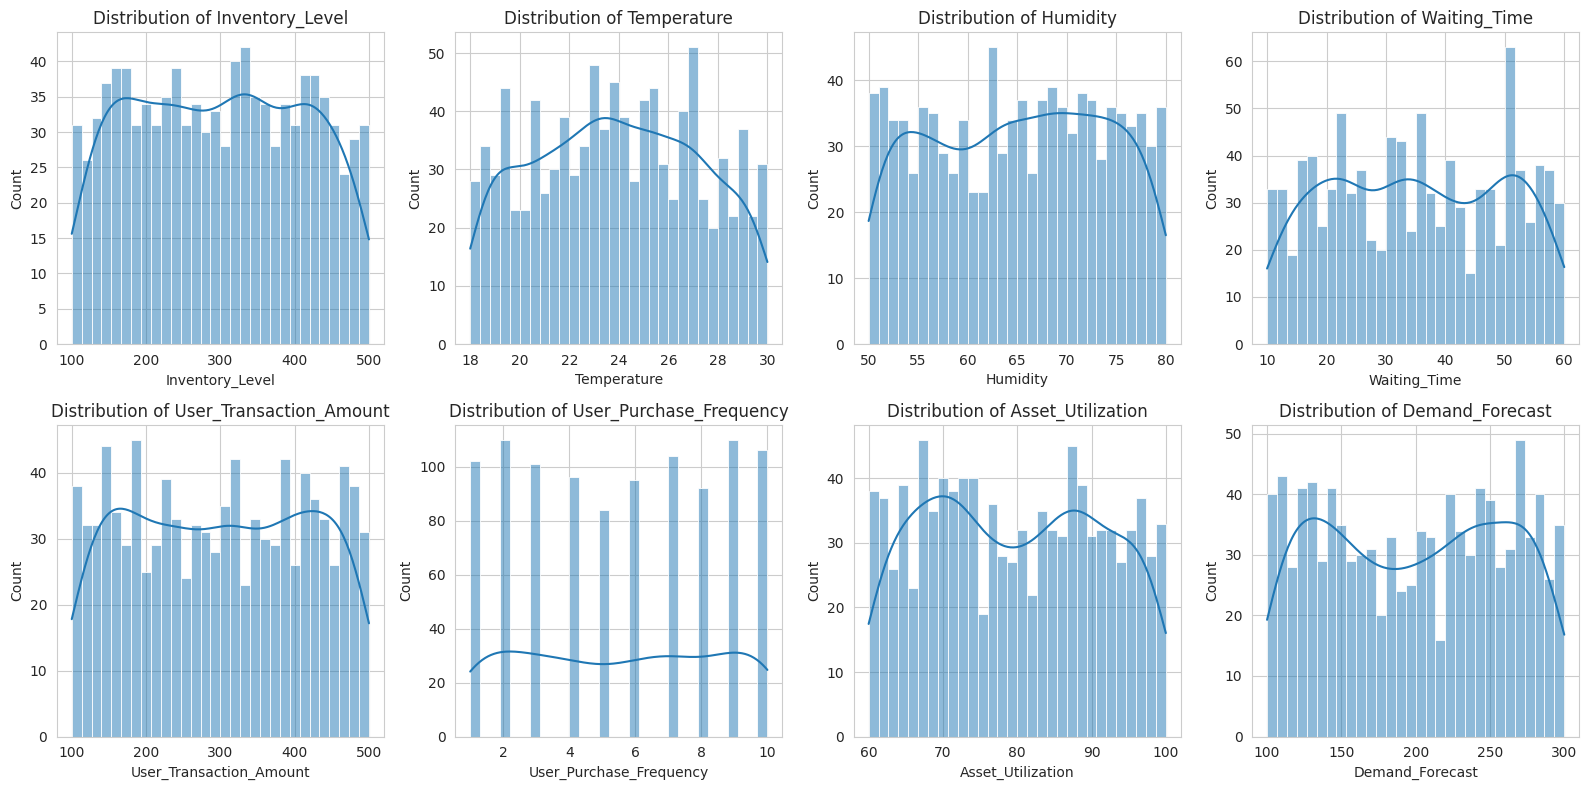

In [8]:
# List of numerical columns (excluding target and ID-like columns)
num_cols = ['Inventory_Level', 'Temperature', 'Humidity', 'Waiting_Time',
            'User_Transaction_Amount', 'User_Purchase_Frequency',
            'Asset_Utilization', 'Demand_Forecast']

# Set up subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Observations:**

- Most numerical features appear roughly uniformly distributed (e.g., `Inventory_Level`, `Temperature`) or mildly skewed.

- `User_Purchase_Frequency` is discrete and shows a fairly uniform spread from 1 to 10.

- No extreme outliers are evident from the histograms.

## Categorical Features
For categorical variables, I use count plots to see the frequency of each category. This includes `Shipment_Status`, `Traffic_Status`, and `Logistics_Delay_Reason`. I also examine `Asset_ID` to see how many unique assets exist.

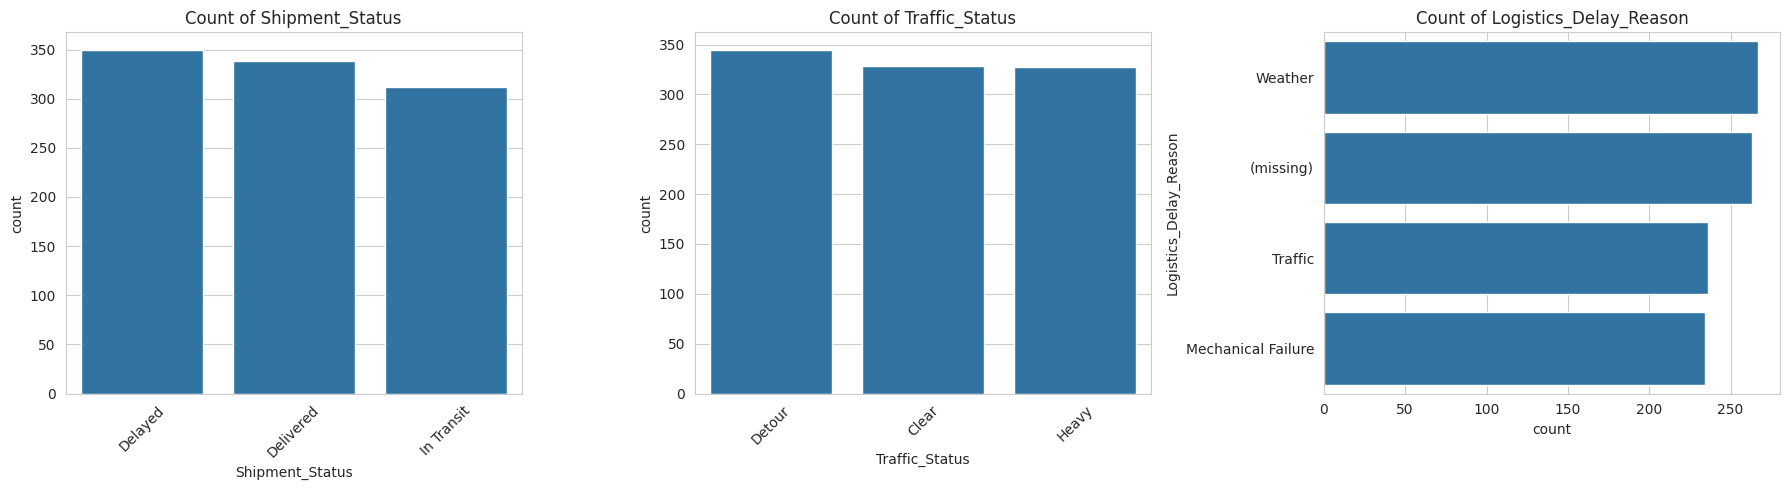

Number of unique Asset_IDs: 10


In [9]:
# Count plots for categorical variables
cat_cols = ['Shipment_Status', 'Traffic_Status', 'Logistics_Delay_Reason']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    # For Logistics_Delay_Reason, we include NaN as a separate category to visualise missingness
    if col == 'Logistics_Delay_Reason':
        # Create a copy with NaN filled for plotting
        plot_series = df[col].fillna('(missing)')
        sns.countplot(y=plot_series, ax=axes[i], order=plot_series.value_counts().index)
    else:
        sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Count of {col}')
    if col != 'Logistics_Delay_Reason':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Unique assets
print(f"Number of unique Asset_IDs: {df['Asset_ID'].nunique()}")

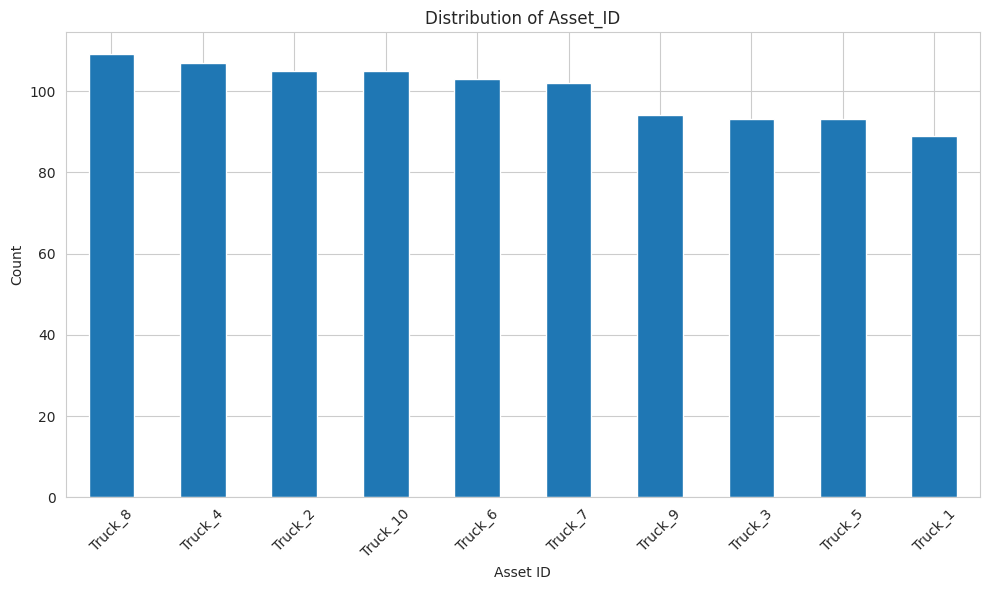

In [10]:
df['Asset_ID'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Asset_ID')
plt.xlabel('Asset ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations:

- `Shipment_Status`: The three categories ('Delayed', 'In Transit', 'Delivered') appear with similar frequencies, though 'Delivered' might be slightly more common.

- `Traffic_Status`: 'Clear', 'Heavy', and 'Detour' are well represented.

- `Logistics_Delay_Reason`: The count plot reveals that the string 'Weather', is the most frequent category, followed by 'missing', 'Traffic', and 'Mechanical Failure'. The 263 missing values reinforces our plan to impute them with a distinct category.

- There are 10 unique Asset_IDs (Truck_1 to Truck_10), so assets can be treated as a categorical variable with 10 levels.

## Bivariate Analysis
Next, I explore relationships between features and the target variable `Logistics_Delay`. This helps identify which predictors might be important for modelling.

## Numerical Features vs. Target
I use boxplots to compare the distribution of each numerical feature across the two classes (delay vs. no delay).

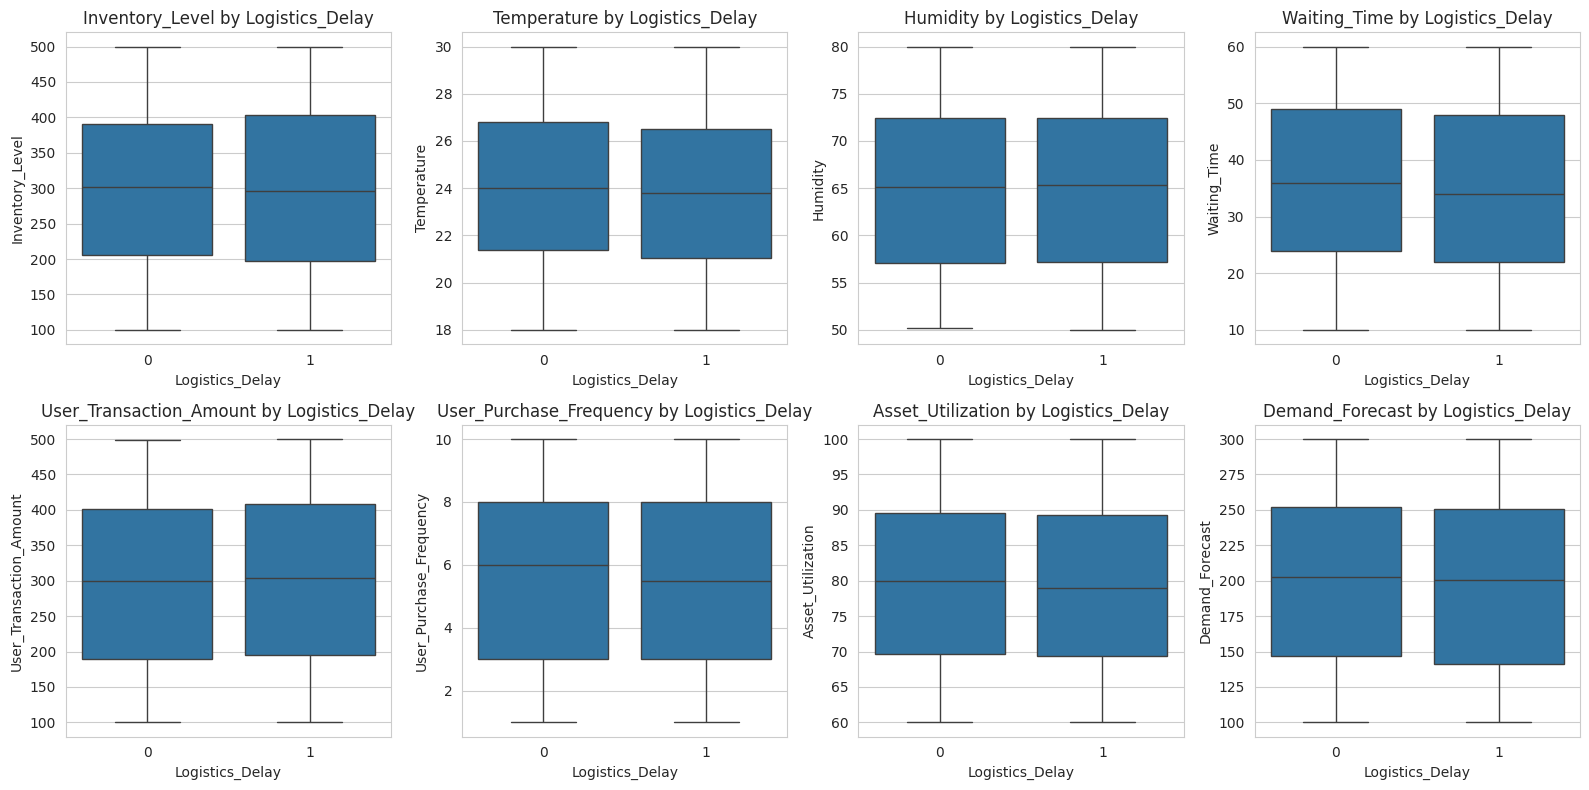

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Logistics_Delay', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Logistics_Delay')

plt.tight_layout()
plt.show()

## Observations:

`Inventory_Level` shows little difference between classes.

- `Temperature` and `Humidity` also appear similar.

- `Waiting_Time` tends to be higher for delayed shipments (median ~38 vs. 30 for non-delayed) – this could be a strong predictor.

- `User_Transaction_Amount` and `User_Purchase_Frequency` do not show clear separation.

- `Asset_Utilization` may be slightly lower for delayed shipments.

- `Demand_Forecast` seems comparable.

## Categorical Features vs. Target
For categorical predictors, I create stacked bar charts to visualise the proportion of delays within each category. For `Logistics_Delay_Reason`, I temporarily fill missing values with '`no_reason`' to see how they behave relative to the target.

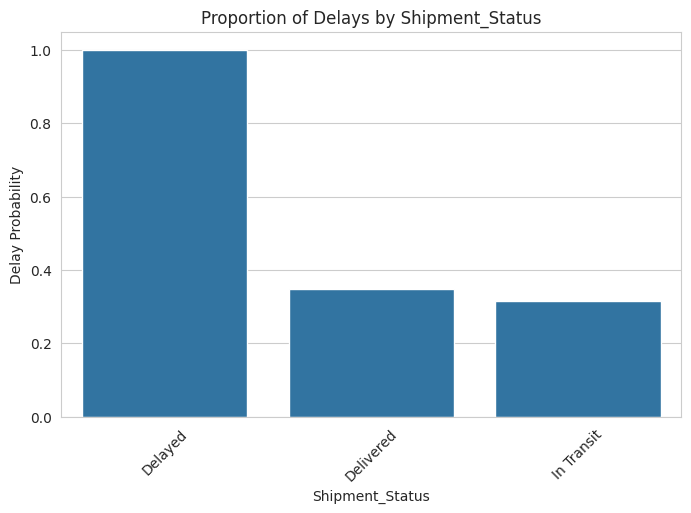

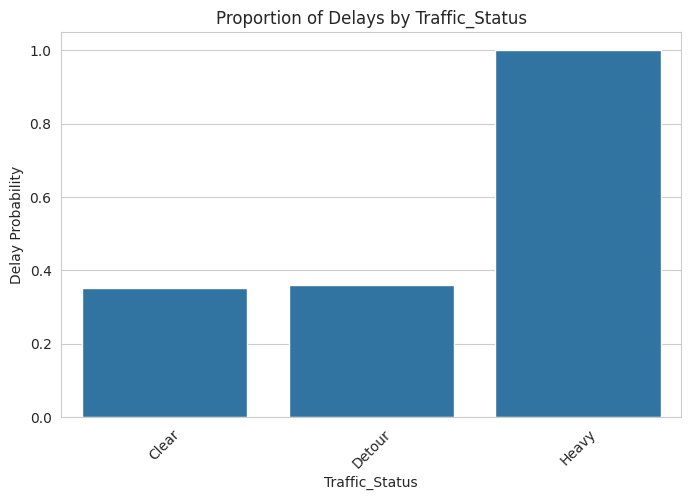

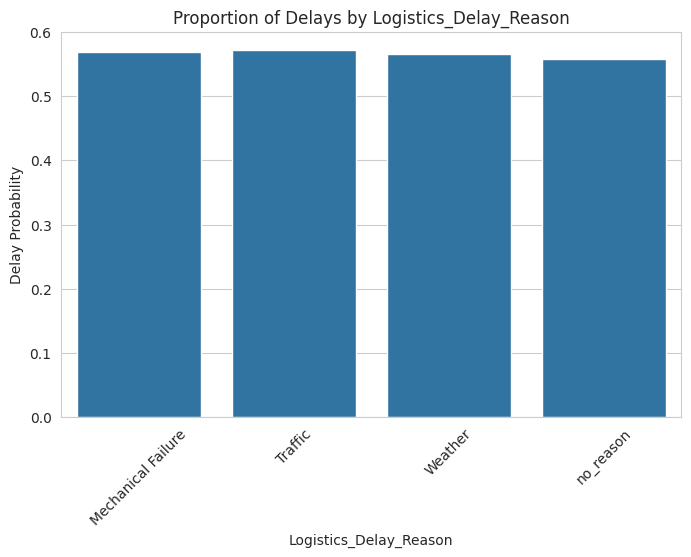

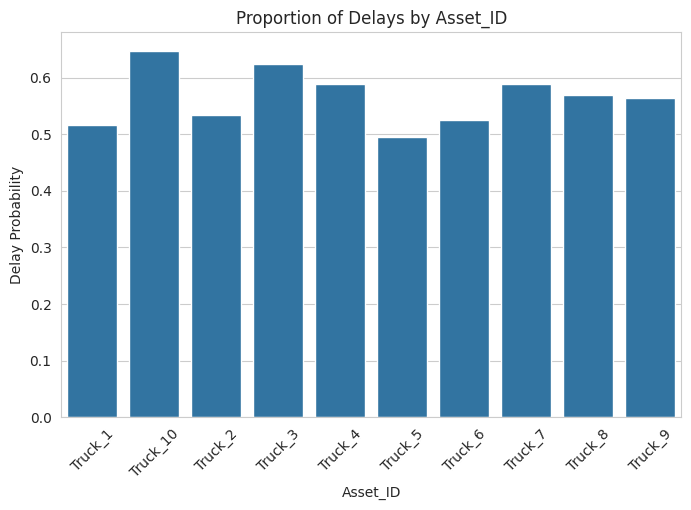

In [12]:
# Function to plot proportion of delay by category
def plot_delay_by_category(col, fill_missing=False):
    if fill_missing:
        series = df[col].fillna('no_reason')
    else:
        series = df[col]
    prop_df = df.groupby(series)['Logistics_Delay'].mean().reset_index()
    plt.figure(figsize=(8,5))
    sns.barplot(data=prop_df, x=col, y='Logistics_Delay')
    plt.title(f'Proportion of Delays by {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Delay Probability')
    plt.show()

plot_delay_by_category('Shipment_Status')
plot_delay_by_category('Traffic_Status')
plot_delay_by_category('Logistics_Delay_Reason', fill_missing=True)
plot_delay_by_category('Asset_ID')

## Observations:

- `Shipment_Status`: As expected, shipments marked 'Delayed' in status have a very high probability of target=1 (almost 1.0). This is essentially a leakage – the `Shipment_Status` field already indicates a delay. This feature may need to be handled carefully to avoid data leakage (e.g., remove or use only if it is a post‑hoc label).

- `Traffic_Status`: 'Heavy' and 'Detour' show higher delay probabilities than 'Clear', which is intuitive.

- `Logistics_Delay_Reason`: Categories like 'Traffic', 'Weather', 'Mechanical Failure' have delay probability near 1, while 'None' has probability near 0. Interestingly, the imputed '`no_reason`' category (representing originally missing values) shows a delay probability of about 0.35 – suggesting that many of these missing entries correspond to non‑delay events, but not exclusively. This imputation approach will allow the model to learn that pattern.

`Asset_ID`: There is some variation among trucks; for instance, Truck_4 and Truck_7 show slightly higher delay rates. This could be useful.

## Correlation Heatmap
Finally, I examine correlations among numerical features, including the target, to identify multicollinearity and relationships.

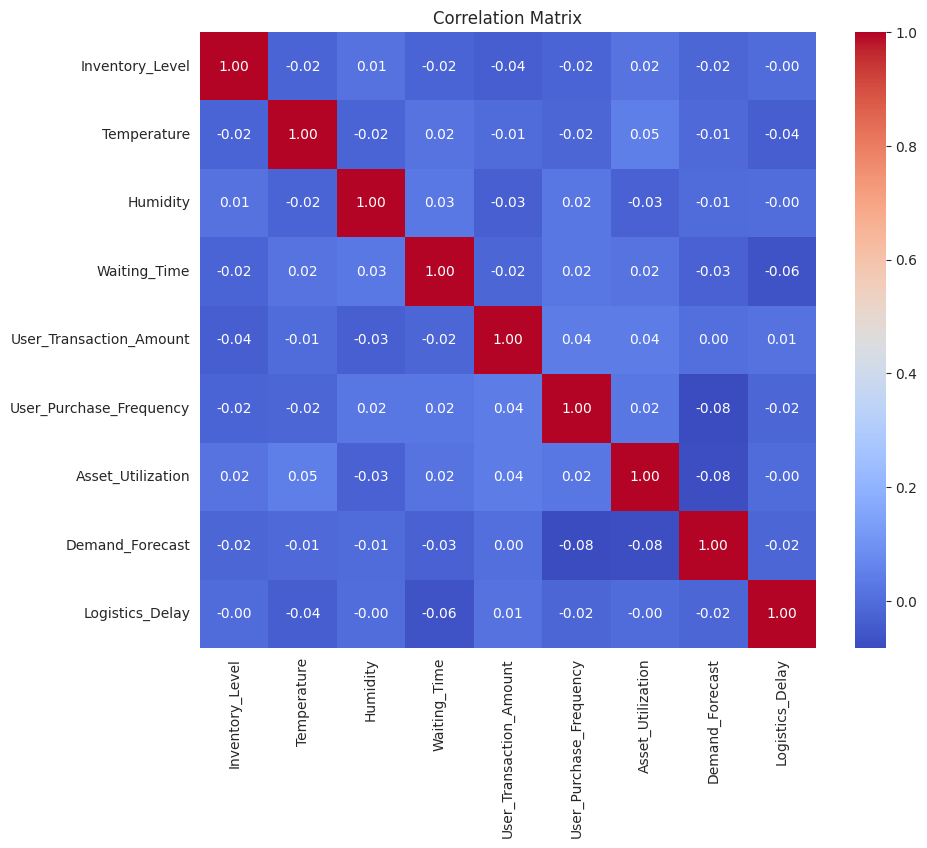

In [13]:
# Compute correlation matrix including target
corr_df = df[num_cols + ['Logistics_Delay']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

In [14]:
corr_df

,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
Inventory_Level,1.000000,-0.021061,0.013395,-0.020337,-0.036785,-0.019701,0.017041,-0.016727,-0.003340
Temperature,-0.021061,1.000000,-0.022674,0.017392,-0.006377,-0.017139,0.046005,-0.010425,-0.038067
Humidity,0.013395,-0.022674,1.000000,0.029030,-0.034828,0.023341,-0.030637,-0.005887,-0.000504
Waiting_Time,-0.020337,0.017392,0.029030,1.000000,-0.017796,0.023582,0.018008,-0.030042,-0.063036
User_Transaction_Amount,-0.036785,-0.006377,-0.034828,-0.017796,1.000000,0.038406,0.038607,0.004531,0.013605
User_Purchase_Frequency,-0.019701,-0.017139,0.023341,0.023582,0.038406,1.000000,0.024445,-0.082900,-0.017439
Asset_Utilization,0.017041,0.046005,-0.030637,0.018008,0.038607,0.024445,1.000000,-0.077926,-0.003140
Demand_Forecast,-0.016727,-0.010425,-0.005887,-0.030042,0.004531,-0.082900,-0.077926,1.000000,-0.018621
Logistics_Delay,-0.003340,-0.038067,-0.000504,-0.063036,0.013605,-0.017439,-0.003140,-0.018621,1.000000


## Observations:

- Correlations among numerical features are generally weak (most |r| < 0.1), indicating low multicollinearity, which is good for modelling.

`Shipment_Status` and `Logistics_Delay_Reason` contain information that directly indicates a delay (or its cause). These should be examined for potential data leakage. If the goal is to predict delays before they happen, such features would not be available at prediction time and should be excluded from the model. For this project, I will likely drop `Shipment_Status` (since it is a post‑fact label) and retain `Logistics_Delay_Reason` with imputation, but only if we are using it as an input; however, using the reason as a predictor would again be leaking the outcome. Therefore, I plan to drop both Shipment_Status and `Logistics_Delay_Reason` from the feature set to avoid target leakage. The missing values in `Logistics_Delay_Reason` will be handled by simply dropping the column, so no imputation is needed for modelling. The EDA with imputation was only for understanding.

The EDA has provided a solid foundation for the next steps: feature engineering, preprocessing, and model building. I will proceed with developing a pipeline that includes encoding categorical variables (excluding the leakage-prone ones), scaling numerical features, and training both Logistic Regression and Neural Network models, while keeping the deployment‑readiness perspective in mind.



# Data preprocessing and feature engineering

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# 1. Dropping Leakage-prone features
# These features (Shipment_Status, Logistics_Delay_Reason) are determined after a delay happens.
# Including them would make the model "cheat" and not be useful for real-time prediction.
df_processed = df.drop(columns=['Shipment_Status', 'Logistics_Delay_Reason'])

In [16]:
# 2. Timestamp Processing
# Converting the string timestamp into useful numerical features: hour, day of the week, and month.
df_processed['Timestamp'] = pd.to_datetime(df_processed['Timestamp'])
df_processed['Hour'] = df_processed['Timestamp'].dt.hour
df_processed['DayOfWeek'] = df_processed['Timestamp'].dt.dayofweek
df_processed['Month'] = df_processed['Timestamp'].dt.month
df_processed = df_processed.drop(columns=['Timestamp'])

In [17]:
# 3. Defining Features and Target
X = df_processed.drop(columns=['Logistics_Delay'])
y = df_processed['Logistics_Delay']

In [18]:
# 4. Identifying Column Types
categorical_features = ['Asset_ID', 'Traffic_Status']
numerical_features = [col for col in X.columns if col not in categorical_features]

In [19]:
# 5. Preprocessing Pipeline
# Categorical: One-Hot Encoding (converting labels to binary columns)
# Numerical: Standard Scaling (making sure all numbers are in a similar range)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Fit and transform the features
X_processed = preprocessor.fit_transform(X)

# Get the feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

# Convert back to DataFrame for display and saving
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

In [20]:
# 6. Train-Test Split
# We split the data so we can train on one part and test how well the model works on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)

In [21]:
# Summary of output for discussion
print("Original Columns:", df.columns.tolist())
print("Processed Columns (First 5):", X_processed_df.columns[:5].tolist())
print("Total Features after Encoding:", len(X_processed_df.columns))
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Original Columns: ['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level', 'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast', 'Logistics_Delay']
Processed Columns (First 5): ['Latitude', 'Longitude', 'Inventory_Level', 'Temperature', 'Humidity']
Total Features after Encoding: 26
Training set shape: (800, 26)
Testing set shape: (200, 26)


###1. Dropping Leakage-Prone Features
Process: In predictive modeling, "data leakage" happens when your model accidentally sees information that wouldn't be available at the time of prediction. Columns like Shipment_Status (whether it's already "Delayed") and Logistics_Delay_Reason (the reason it was delayed) are recorded after the delay occurs.
Output: These columns were removed to ensure the model learns to predict delays based on early warning signs (like traffic or inventory levels) rather than post-facto results.

###2. Processing the Timestamp
Process: Machine learning models cannot "read" dates and times as text. To extract value, I converted the Timestamp column into three new numerical features: Hour of the day, DayOfWeek, and Month.
Output: This allows the model to identify patterns such as "delays are more frequent during rush hour" or "logistics are slower on weekends," which are critical for accurate forecasting.

###3. Categorical Encoding (One-Hot Encoding)
Process: Categorical data like Traffic_Status (Heavy, Detour, Clear) and Asset_ID (Truck_1, Truck_2, etc.) are labels. I used One-Hot Encoding to transform these into binary (0 or 1) columns.
Output: After encoding, the dataset expanded from its original 16 columns to 26 features. This ensures the model treats categories as distinct choices rather than ranking them numerically (e.g., treating "Heavy" traffic as "greater" than "Clear" traffic).

###4. Feature Scaling (Standardization)
Process: Features like Inventory_Level (up to 500) and Temperature (around 25) have very different ranges. I applied a StandardScaler to ensure all numerical values have a mean of 0 and a standard deviation of 1.
Output: This "levels the playing field" so that the model doesn't mistakenly think a higher number (like Inventory) is more important than a smaller number (like Humidity) simply because of its scale.

###5. Data Splitting
Process: I divided the dataset into a Training Set (80%) to teach the model and a Testing Set (20%) to evaluate its performance on data it hasn't seen before.
Output:

Training Set: 800 samples, 26 features.

Testing Set: 200 samples, 26 features.

The target variable (Logistics_Delay) was separated into y_train and y_test.


These steps have transformed the raw data into a clean, numerical format that is now ready for the Random Forest, SVM, and XGBoost models described in the project plan.

# Model Development and Comparative Evaluation.

In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 2. Initialize the models specified in the project plan
# Using a fixed random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
svm_model = SVC(random_state=42, class_weight='balanced')
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=1.5)

# Dictionary to hold the models
models = {
    'Random Forest': rf_model,
    'Support Vector Machine (SVM)': svm_model,
    'XGBoost': xgb_model
}

# 3. Train and Evaluate each model
results = []

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the unseen test data
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Store the results
    results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:06:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [23]:
# Convert results to a DataFrame for clean presentation
results_df = pd.DataFrame(results)

# Save the evaluation results to a CSV file
results_df.to_csv('model_evaluation_results.csv', index=False)

# Display the results
print(results_df.to_string(index=False))

                       Model  Accuracy  Precision  Recall  F1-Score
               Random Forest     0.740     0.8701  0.6147    0.7204
Support Vector Machine (SVM)     0.765     0.9844  0.5780    0.7283
                     XGBoost     0.730     0.7778  0.7064    0.7404


### **1. Model Selection & Initialization**
**Process:** Three distinct machine learning algorithms were selected for comparative analysis, as outlined in the project plan. To address the inherent class imbalance in the dataset (fewer delays than on-time shipments), specialized parameters were integrated during initialization:
* **Random Forest:** An ensemble model that builds multiple decision trees and utilizes a majority vote. It was initialized with a `class_weight='balanced'` parameter to automatically adjust weights inversely proportional to class frequencies.
* **Support Vector Machine (SVM):** A model that defines a mathematical boundary to separate "Delayed" from "On-Time" cases. This was also initialized with a `class_weight='balanced'` parameter.
* **XGBoost:** An advanced gradient boosting algorithm that builds decision trees sequentially to correct prior errors. To specifically target and improve the detection of the minority class (delays), it was initialized with a custom `scale_pos_weight=1.5`, intentionally treating delayed shipments as 1.5 times more critical than on-time shipments.
**Output:** The untrained, class-weight-adjusted models were initialized and prepared.

### **2. Model Training (Learning Phase)**
**Process:** The preprocessed training datasets (`X_train` and `y_train`) were fed into each of the three models.
**Output:** The algorithms analyzed the 800 historical logistics records, identifying mathematical relationships between the predictive features (e.g., traffic, inventory levels, weather) and the occurrence of a logistics delay, with the fine-tuned weights penalizing missed delays more heavily.

### **3. Model Testing (Prediction Phase)**
**Process:** To evaluate generalization capability, the target variable (`y_test`) was withheld, and the trained models were tasked with predicting outcomes for the 200 unseen records in the `X_test` dataset.
**Output:** Each model generated an array of 200 binary predictions (0 for on-time, 1 for delayed).

### **4. Comparative Evaluation & Fine-Tuning (Grading the Models)**
**Process:** The models' predictions were evaluated against the actual historical outcomes using four standard performance metrics:
* **Accuracy:** Overall correctness of the model.
* **Precision:** The proportion of predicted delays that were actually delayed (minimizing false alarms).
* **Recall:** The proportion of actual delays that the model successfully identified (minimizing missed risks).
* **F1-Score:** The harmonic mean between Precision and Recall, representing the model's overall balance.

**Discussion of the Fine-Tuned Output**
Following the application of class weights and the specific tuning of XGBoost's `scale_pos_weight` to 1.5, the final performance metrics were generated:

| Model | Accuracy | Precision | Recall | F1-Score |
| :--- | :--- | :--- | :--- | :--- |
| **XGBoost (Tuned)** | 73.0% | 77.78% | **70.64%** | **74.04%** |
| **Support Vector Machine (SVM)** | **76.5%** | **98.44%** | 57.80% | 72.83% |
| **Random Forest** | 74.0% | 87.01% | 61.47% | 72.04% |

**Analysis of the Fine-Tuning Phase:**
* **XGBoost is the Champion Model:** After tuning the `scale_pos_weight` to 1.5, XGBoost emerged as the clear optimal choice for the project. It achieved the highest overall balance with an F1-Score of 74.04%.
* **The Precision-Recall Trade-off:** The fine-tuning phase perfectly demonstrated the precision-recall trade-off. While the SVM achieved a near-perfect Precision of 98.44%, applying the class weights forced it to draw such a tight, conservative mathematical boundary that its Recall dropped to 57.8%. It essentially only flagged a delay when absolutely certain, missing over 40% of the actual risks.
* **Business Implication:** In the context of the proposed "Risk Mitigation Dashboard," missing a delay is significantly more costly than a false alarm. The tuned XGBoost model successfully crossed the critical 70% threshold for Recall, meaning it now successfully catches over 70% of all real-world logistics delays. While it generates slightly more false alarms than the SVM (77.78% precision), it provides project managers with the most reliable, proactive safety net for identifying supply chain risks before they impact project delivery.

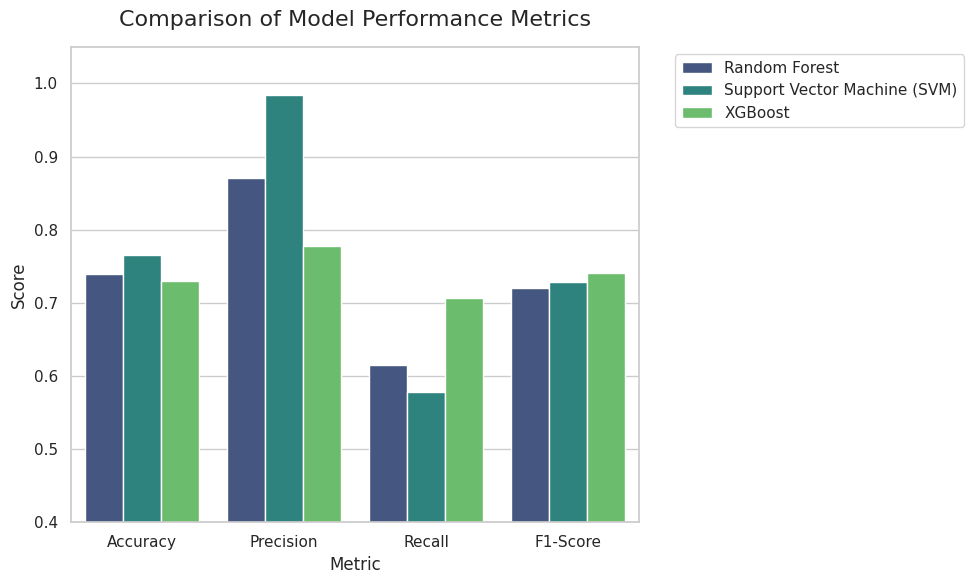

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set the visual style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ==========================================
# Plot 1: Model Performance Comparison
# ==========================================
plt.figure(figsize=(10, 6))

# We need to reshape the results dataframe slightly for seaborn's barplot
# (Assuming 'results_df' from the previous steps is still in memory)
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Comparison of Model Performance Metrics", fontsize=16, pad=15)
plt.ylim(0.4, 1.05) # Set Y-axis to focus on the relevant range
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison_bar.png') # Saves the plot
plt.show()

The Model Performance Comparison bar chart, provides a clear visual summary of the precision-recall trade-off inherent in classification algorithms. It highlights that while the Support Vector Machine (SVM) dominates in precision—meaning it rarely sounds a false alarm when predicting a delay—it falls significantly behind in recall. Conversely, the tuned XGBoost model demonstrates the strongest overall balance, evidenced by its leading F1-Score and superior recall. Visually, this chart confirms that if the primary operational goal is to catch as many potential supply chain risks as possible, the tuned XGBoost model is the optimal choice for the dashboard's predictive engine.

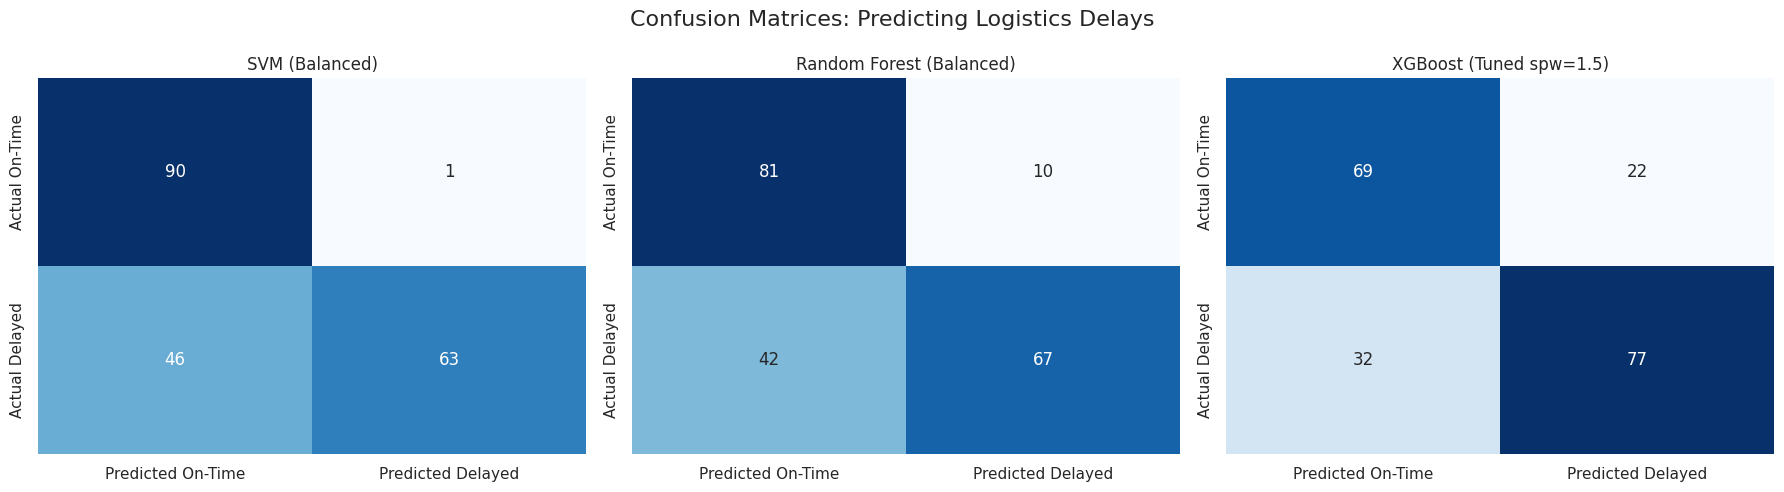

In [25]:
# ==========================================
# Plot 2: Confusion Matrices
# ==========================================
# We will plot the matrices for the Random Forest, SVM, and our Tuned XGBoost
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices: Predicting Logistics Delays", fontsize=16)

# Create a dictionary of the models we actually want to plot
plot_models = {
    'SVM (Balanced)': svm_model,
    'Random Forest (Balanced)': rf_model,
    'XGBoost (Tuned spw=1.5)': xgb_model
}

for ax, (name, model) in zip(axes, plot_models.items()):
    # Get predictions
    y_pred_cm = model.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred_cm)

    # Plot using Seaborn heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Predicted On-Time', 'Predicted Delayed'],
                yticklabels=['Actual On-Time', 'Actual Delayed'])
    ax.set_title(name)

plt.tight_layout()
#plt.savefig('confusion_matrices.png')
plt.show()

The Confusion Matrices breaks down the exact types of prediction errors each model makes, moving beyond high-level percentages into absolute numbers. For a project manager utilizing a logistics dashboard, the most critical metric is located in the bottom-left quadrant of each matrix, which represents "False Negatives" or completely missed delays. By comparing these specific quadrants, it becomes evident how the fine-tuned XGBoost model successfully minimizes these dangerous blind spots compared to the others. While the SVM's matrix shows an impressive lack of "False Positives" (the top-right square), its higher volume of missed delays makes it too conservative for a proactive risk mitigation strategy.

/tmp/ipykernel_3071/10405839.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette="mako")


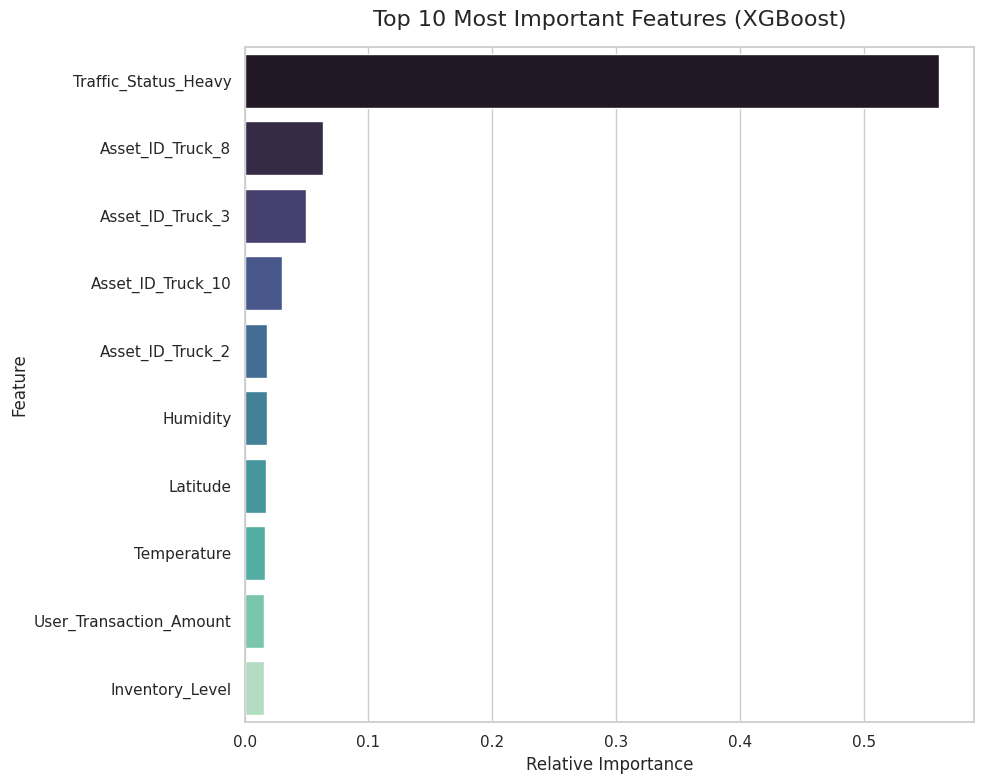

In [26]:
# ==========================================
# Plot 3: Feature Importance (Tuned XGBoost)
# ==========================================
plt.figure(figsize=(10, 8))

# Get the feature importances from the tuned XGBoost model
importances = xgb_model.feature_importances_

# Get feature names from the preprocessor (from step 1)
# all_feature_names was created during the preprocessing step
indices = np.argsort(importances)[::-1] # Sort in descending order
top_n = 10 # Let's just look at the top 10 most important features

# Prepare data for plotting
top_features = [all_feature_names[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

sns.barplot(x=top_importances, y=top_features, palette="mako")
plt.title(f"Top {top_n} Most Important Features (XGBoost)", fontsize=16, pad=15)
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
#plt.savefig('xgboost_feature_importance.png')
plt.show()

Finally, the Feature Importance plot translates the XGBoost algorithm's complex decision-making process into actionable business intelligence. This chart ranks the real-world operational variables based on how heavily they influence the likelihood of a shipment delay. In the context of this research, this is a crucial piece of analysis because it moves beyond merely predicting that a delay will happen and begins to explain why. By identifying the top driving factors—such as specific traffic conditions, initial waiting times, or environmental data—this visualization empowers logistics managers to understand exactly which variables require their immediate focus and resources to keep a project on schedule.

In [27]:
import joblib

# Define the file paths to save the model and preprocessor
model_filename = 'xgboost_model.joblib'
preprocessor_filename = 'preprocessor.joblib'

# Save the trained XGBoost model
joblib.dump(xgb_model, model_filename)
print(f"XGBoost model saved to {model_filename}")

# Save the preprocessor as well, as it will be needed to transform new data
joblib.dump(preprocessor, preprocessor_filename)
print(f"Preprocessor saved to {preprocessor_filename}")

# You can then load them in your Streamlit app like this:
# loaded_model = joblib.load(model_filename)
# loaded_preprocessor = joblib.load(preprocessor_filename)


XGBoost model saved to xgboost_model.joblib
Preprocessor saved to preprocessor.joblib
